# Data Preparation
In this notebook we prepare and enrich the data with additional metadata (published year, author's demographics)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import random
from utils.date_extraction import *

## Loading the raw datasets

### Loading Project Gutenberg dataset from kaggle

In [3]:
# Downloading or loading Project Gutenberg
path_to_kaggle_cache = '/Users/eglantinevialaneix'
raw_metadata_df, path_to_cached_gutenberg = load_gutenberg(your_path=path_to_kaggle_cache, DOWNLOAD=False)

metadata_df = clean_gutenberg(raw_metadata_df)

Successfully loaded the metadata dataframe.
Path to cached dataset files: /Users/eglantinevialaneix/.cache/kagglehub/datasets/lokeshparab/gutenberg-books-and-metadata-2025/versions/4/
Dropped 16402 books where Language ≠ english or Type ≠ Text.
Kept only 7 columns.


In [4]:
check_folder_size(path_to_cached_gutenberg)
check_memory_usage()

Folder size: 28.86 GB
Total memory: 460.43 GB
Memory used: 313.32 GB = 68.05 %
Free memory: 147.11 GB = 31.95 %


### Loading the Chronoberg Dataset, with annotated years

In [5]:
# Change here the path to Chronoberg dataset. Downloadable at 
# https://huggingface.co/datasets/spaul25/Chronoberg/resolve/main/dataset/Chronoberg_raw.jsonl?download=true

path_to_enormous_jsonl = "../../../../../Downloads/history/Chronoberg_raw.jsonl"

print(f"The Chronoberg Dataset file takes {os.path.getsize(path_to_enormous_jsonl) / 1e9:.2f} GB of memory.")
df_chronoberg = load_chronoberg_json(path_to_enormous_jsonl)
df_chronoberg

The Chronoberg Dataset file takes 10.40 GB of memory.


year,text
i64,str
1979,""" Transcriber's note: Exten…"
1753,""" LETTERS TO…"
1789,""" Persuasion by Jane Auste…"
1779,""" THE WRITINGS OF THOMAS PA…"
1844,""" THE LIFE OF FRANCIS MARIO…"
…,…
1786,""" Henry Clay, ""On the…"
1866,""" Transcribed from the 1894…"
1850,""" The Scarlet Letter by Nat…"


## Extracting the published years of the books

### Comparing the 2 datasets

In [7]:
metadata_df

,Etext Number,Title,Authors,LoCC,Bookshelves,Subjects,rights
0,1,The Declaration of Independence of the United ...,"Jefferson, Thomas",E201; JK,Politics; American Revolutionary War; United S...,E201 ; JK ; United States -- History -- Revolu...,Public domain in the USA.
1,2,The United States Bill of Rights\r\nThe Ten Or...,United States,JK; KF,Politics; American Revolutionary War; United S...,Civil rights -- United States -- Sources ; JK ...,Public domain in the USA.
2,3,John F. Kennedy's Inaugural Address,"Kennedy, John F. (John Fitzgerald)",E838,Browsing: History - American; Browsing: Politics,E838 ; United States -- Foreign relations -- 1...,Public domain in the USA.
3,4,Lincoln's Gettysburg Address\r\nGiven November...,"Lincoln, Abraham",E456,US Civil War; Browsing: History - American; Br...,E456 ; Soldiers' National Cemetery (Gettysburg...,Public domain in the USA.
4,5,The United States Constitution,United States,JK; KF,United States; Politics; American Revolutionar...,JK ; United States. Constitution ; United Stat...,Public domain in the USA.
...,...,...,...,...,...,...,...
75387,75563,"Cedar chests, how to make them","Windoes, Ralph Flagg, 1891-1967",TT,NaN,Chests,NaN
75388,75564,The puzzle of life,"Nicols, Arthur",NaN,NaN,NaN,NaN
75389,75565,The man with a grouch,"Stacpoole, H. De Vere (Henry De Vere), 1863-1951",NaN,NaN,NaN,NaN
75390,75566,Visibility—Zero,"Stearns, Myron M. (Myron Morris), 1884-1963",NaN,NaN,NaN,NaN


In [8]:
metadata_df.columns

Index(['Etext Number', 'Title', 'Authors', 'LoCC', 'Bookshelves', 'Subjects',
       'rights'],
      dtype='str')

In [9]:
all_book_ids = raw_metadata_df["Etext Number"].astype(int).to_list()
all_book_ids.sort()

all_books_filenames = os.listdir(path_to_cached_gutenberg + "/books")
all_books_filenames = [int(book_id) for book_id in all_books_filenames]
all_books_filenames.sort()


print("Number of book ids in metadata: ", len(all_book_ids))
print("Number of books present in the dataset: ", len(all_books_filenames))
print("Delta = ", len(all_book_ids) - len(all_books_filenames))

all_books_filenames_set = set(all_books_filenames)
all_book_ids_set = set(all_book_ids)

missing_metadata = list(all_books_filenames_set - all_book_ids_set)
missing_files = list(all_book_ids_set - all_books_filenames_set)

print(f"Missing books in dataset: {len(missing_files)} among which {sum(metadata_df["Etext Number"].isin(missing_files))} are english text.")
print("Missing metadata: ", len(missing_metadata))

Number of book ids in metadata:  75394
Number of books present in the dataset:  75370
Delta =  24
Missing books in dataset: 24 among which 22 are english text.
Missing metadata:  0


In [10]:
book_ids = metadata_df["Etext Number"][~metadata_df["Etext Number"].isin(missing_files)].apply(str).to_list()
book_ids

['1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '51',
 '53',
 '54',
 '55',
 '56',
 '57',
 '58',
 '59',
 '60',
 '61',
 '62',
 '63',
 '64',
 '66',
 '67',
 '68',
 '69',
 '70',
 '71',
 '72',
 '73',
 '74',
 '75',
 '76',
 '77',
 '78',
 '79',
 '80',
 '81',
 '82',
 '83',
 '84',
 '85',
 '86',
 '87',
 '88',
 '90',
 '91',
 '92',
 '93',
 '94',
 '95',
 '96',
 '97',
 '98',
 '99',
 '100',
 '101',
 '102',
 '103',
 '104',
 '105',
 '106',
 '107',
 '108',
 '109',
 '110',
 '111',
 '112',
 '113',
 '115',
 '117',
 '118',
 '119',
 '120',
 '121',
 '122',
 '123',
 '124',
 '125',
 '126',
 '128',
 '130',
 '131',
 '132',
 '133',
 '134',
 '135',
 '136',
 '137',
 '138',
 '139',
 '140',
 '141',
 '142',
 '143',
 '144',
 '145',
 '146',


In [11]:
path_to_fulltexts = os.path.join(path_to_cached_gutenberg, "books")

a_random_book = random.choice(book_ids)
with open(os.path.join(path_to_fulltexts, a_random_book), 'r') as f:
    print(f.read(2000))

The Project Gutenberg eBook of Under the Greenwood Tree, by Thomas Hardy

This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online at
www.gutenberg.org. If you are not located in the United States, you
will have to check the laws of the country where you are located before
using this eBook.

Title: Under the Greenwood Tree

Author: Thomas Hardy

Release Date: June, 2001 [eBook #2662]
[Most recently updated: November 17, 2023]

Language: English

Produced by: David Price, Margaret Rose Price and Dagny

*** START OF THE PROJECT GUTENBERG EBOOK UNDER THE GREENWOOD TREE ***




UNDER THE GREENWOOD TREE

or

THE MELLSTOCK QUIRE
A RURAL PAINTING OF THE DUTCH SCHOOL

by Thomas Hardy




Contents


 PREFACE

 PART THE FIRST—WINTER
 CHAPTER I. MELLSTOCK-LANE
 CHAPTER II. TH

### Extracting the books present in Chronoberg's rows

To each book id that is present in Chronoberg, we retrieved its published year from Chronoberg

In [13]:
extract_years_from_scratch = False

if extract_years_from_scratch:
    # This command takes approx. 30 min to run
    results = pd.DataFrame(
        extract_books_fast(df_chronoberg, book_ids, path_to_fulltexts),
        columns=["Published Year", "Etext Number"]
    )

In [14]:
overwrite_extracted_years = False  # ⚠️ if you put this to True, make sure you reran the previous cell as well
load_extracted_years = not overwrite_extracted_years

if overwrite_extracted_years:
    results.to_csv("../../data/metadata_files/years_and_booksIDs.csv")
    print("Overwrote and saved extracted years.")
    
elif load_extracted_years:
    results = pd.read_csv("../../data/metadata_files/years_and_booksIDs.csv", index_col=0)
    print("Loaded the extracted years.")
    
else:
    raise NotImplementedError("Did not write nor load any years_and_booksIDs.csv file. Choose if you want to overwrite or load said csv file using the boolean variables.")

Loaded the extracted years.


In [15]:
results

,Published Year,Etext Number
0,1979,52532
1,1979,63675
2,1979,51039
3,1979,38035
4,1979,74349
...,...,...
32742,1759,62372
32743,1759,44381
32744,1759,19942
32745,1759,3359


### Joining the published years on the Gutenberg metadata

In [16]:
join_and_overwrite = False
load_merged_metadata = not join_and_overwrite

if join_and_overwrite:
    metadata_with_years = metadata_df.merge(results, on="Etext Number")
    metadata_with_years.to_csv("../../data/metadata_files/metadata_with_years.csv")
    print("Joined years with metadata. Overwrote and saved metadata with extracted years.")
elif load_merged_metadata:
    metadata_with_years = pd.read_csv("../../data/metadata_files/metadata_with_years.csv", index_col=0)
    print("Loaded the metadata with years.")
else:
    raise NotImplementedError("Did not merge nor load any metadata_with_years.csv file. Choose if you want to merge and overwrite or load said csv file using the boolean variables.")

metadata_with_years

Loaded the metadata with years.


,Etext Number,Title,Authors,LoCC,Bookshelves,Subjects,rights,Published Year
0,1,The Declaration of Independence of the United ...,"Jefferson, Thomas",E201; JK,Politics; American Revolutionary War; United S...,E201 ; JK ; United States -- History -- Revolu...,Public domain in the USA.,1878
1,3,John F. Kennedy's Inaugural Address,"Kennedy, John F. (John Fitzgerald)",E838,Browsing: History - American; Browsing: Politics,E838 ; United States -- Foreign relations -- 1...,Public domain in the USA.,1776
2,5,The United States Constitution,United States,JK; KF,United States; Politics; American Revolutionar...,JK ; United States. Constitution ; United Stat...,Public domain in the USA.,1776
3,6,Give Me Liberty or Give Me Death,"Henry, Patrick",E201,American Revolutionary War; Browsing: History ...,E201 ; United States -- Politics and governmen...,Public domain in the USA.,1878
4,8,Abraham Lincoln's Second Inaugural Address,"Lincoln, Abraham",E456,US Civil War; Browsing: History - American; Br...,E456 ; United States -- Politics and governmen...,Public domain in the USA.,1861
...,...,...,...,...,...,...,...,...
32742,75551,Reminiscences of the South Seas,"La Farge, John",NaN,NaN,NaN,Public domain in the USA.,1979
32743,75553,Among the camps,"Page, Thomas Nelson",NaN,NaN,NaN,Public domain in the USA.,1902
32744,75559,"The journal of George Fox, vol. 1 of 2","Fox, George, 1624-1691; Fox, Margaret Askew Fe...",NaN,NaN,NaN,NaN,1789
32745,75561,Some old masters of Greek architecture,"Douglas, Harry, 1857-1938; Farrand, Charles D....",NaN,NaN,"Architecture, Greek; Architecture -- Greece",NaN,1979


### Short inspection of years distribution

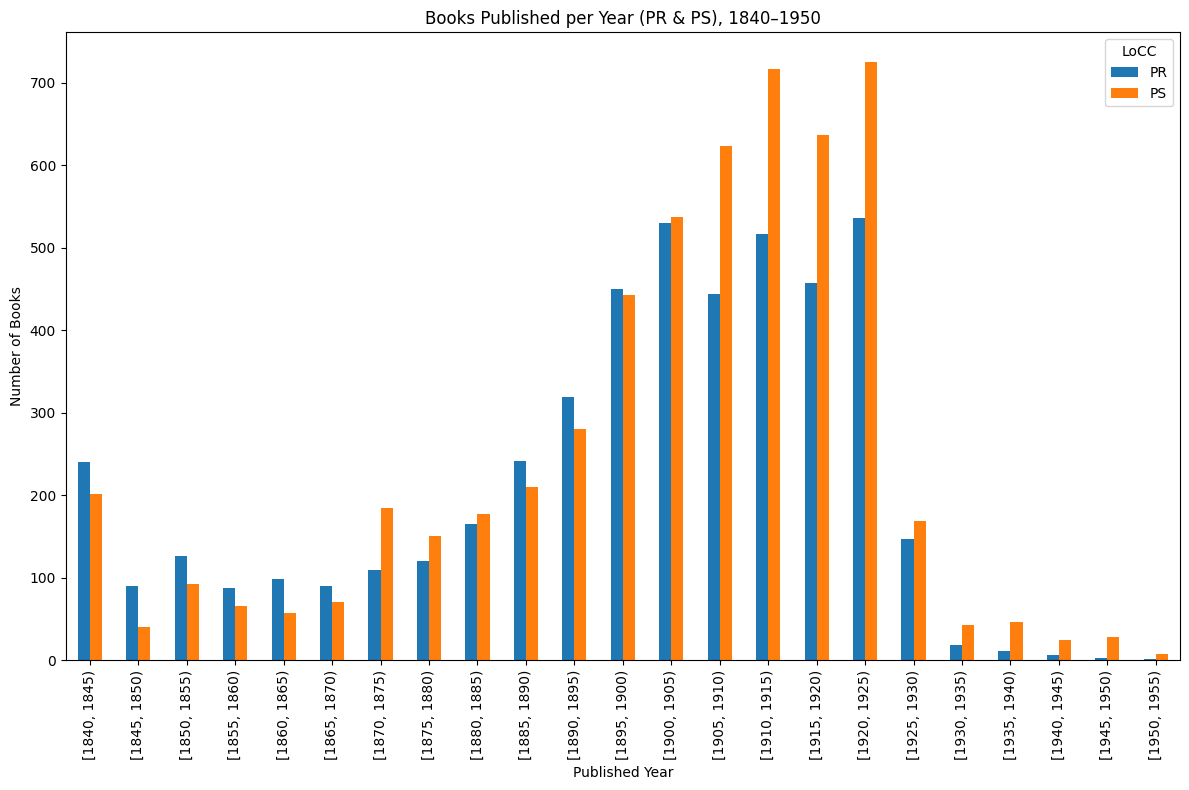

In [17]:
fig, ax = plt.subplots(figsize=(12, 8))

mask = (
    metadata_with_years["LoCC"].isin({'PR', 'PS'}) &
    metadata_with_years["Published Year"].between(1840, 1950)
)

bins = range(1840, 1956, 5)

df = metadata_with_years[mask].copy()
df["Year Bin"] = pd.cut(df["Published Year"], bins=bins, right=False)

(
    df.groupby(["Year Bin", "LoCC"])
    .size()
    .unstack("LoCC")
    .plot.bar(ax=ax)
)

ax.set_xlabel("Published Year")
ax.set_ylabel("Number of Books")
ax.set_title("Books Published per Year (PR & PS), 1840–1950")
plt.tight_layout()
plt.show()

## Extracting the authors information from Wikipedia API

We need to find the authors genders for the rest of our analysis.

In [ ]:
from utils.author_gender import *

### Cleaning the authors

In [28]:
# Masks
is_US_UK_literature = metadata_with_years["LoCC"].isin(["PR", "PS"])
was_published_during_period =  (1870 <= metadata_with_years["Published Year"]) & (metadata_with_years["Published Year"] <= 1920)

# Metadata of interest
authors_of_interest = metadata_with_years[is_US_UK_literature & was_published_during_period][["Authors", "Etext Number", "Published Year"]]

# some cleaning on authors' names
authors_of_interest = authors_of_interest[~authors_of_interest["Authors"].isna()]
authors_of_interest["Authors"] = authors_of_interest["Authors"].str.split(";")
authors_of_interest = authors_of_interest.explode("Authors")
authors_of_interest

,Authors,Etext Number,Published Year
9,"Carroll, Lewis",13,1876
17,"Cather, Willa",24,1913
18,"Hardy, Thomas",27,1874
21,"Gilman, Charlotte Perkins",32,1915
23,"Wells, H. G. (Herbert George)",35,1895
...,...,...,...
32678,"Gordon, Homer King",75097,1903
32700,"Hackett, Walter",75246,1919
32700,"Megrue, Roi Cooper",75246,1919
32731,"Southworth, Emma Dorothy Eliza Nevitte",75497,1885


In [29]:
authors_counts = authors_of_interest["Authors"].value_counts()
authors_counts

Authors
Parker, Gilbert          131
Twain, Mark              100
James, Henry              66
Doyle, Arthur Conan       55
Howells, William Dean     48
                        ... 
Ganthony, Richard          1
Gordon, Homer King         1
Hackett, Walter            1
 Megrue, Roi Cooper        1
Trench, Herbert            1
Name: count, Length: 2240, dtype: int64

In [36]:
authors_one_book = authors_counts[authors_counts.values == 1].index
authors_one_book

Index(['Irving, Washington', 'Austen, Jane', ' Corson, Hiram', 'Kilmer, Joyce',
       'Drake, Joseph Rodman', 'Davis, Rebecca Harding', 'Eastman, Charles A.',
       'McCrae, John', 'Gaskell, Elizabeth Cleghorn', 'Tuckwell, William',
       ...
       'Moffett, Cleveland ', 'Paine, Ralph Delahaye', 'Staats, William',
       'Coxwell, Henry Tracey', 'Carling, John R.', 'Ganthony, Richard',
       'Gordon, Homer King', 'Hackett, Walter ', ' Megrue, Roi Cooper',
       'Trench, Herbert'],
      dtype='str', name='Authors', length=1294)

In [37]:
print(f"{100 * len(authors_one_book) / len(authors_counts):.2f}")

57.77


Almost 60 % of the authors only have one book in the dataset. It is highly probable that we will not find any information on these authors in our extraction. To cite the prof when he was citing another wise professor: this is the slaughterhouse of history snif.

In [38]:
all_authors = authors_counts.index
all_authors

Index(['Parker, Gilbert', 'Twain, Mark', 'James, Henry', 'Doyle, Arthur Conan',
       'Howells, William Dean', 'Oppenheim, E. Phillips (Edward Phillips)',
       'Haggard, H. Rider (Henry Rider)', 'Le Queux, William', 'London, Jack',
       'Wells, H. G. (Herbert George)',
       ...
       'Moffett, Cleveland ', 'Paine, Ralph Delahaye', 'Staats, William',
       'Coxwell, Henry Tracey', 'Carling, John R.', 'Ganthony, Richard',
       'Gordon, Homer King', 'Hackett, Walter ', ' Megrue, Roi Cooper',
       'Trench, Herbert'],
      dtype='str', name='Authors', length=2240)

In [ ]:
# For API's User Agent: authentify yourself here
your_email = "eglantine.vialaneix@epfl.ch"

In [60]:
# This cell takes approx. 100 min to run
authors_info_df, not_found = scrape_authors(all_authors, delay=1)

12:38:58  INFO      Progress: 50 / 2240
12:40:28  INFO      Progress: 100 / 2240
12:42:16  INFO      Progress: 150 / 2240
12:44:10  INFO      Progress: 200 / 2240
12:45:50  INFO      Progress: 250 / 2240
12:47:40  INFO      Progress: 300 / 2240
12:49:41  INFO      Progress: 350 / 2240
12:51:57  INFO      Progress: 400 / 2240
12:53:55  INFO      Progress: 450 / 2240
12:55:54  INFO      Progress: 500 / 2240
12:58:00  INFO      Progress: 550 / 2240
13:00:06  INFO      Progress: 600 / 2240
13:02:00  INFO      Progress: 650 / 2240
13:03:59  INFO      Progress: 700 / 2240
13:06:10  INFO      Progress: 750 / 2240
13:08:14  INFO      Progress: 800 / 2240
13:10:17  INFO      Progress: 850 / 2240
13:12:28  INFO      Progress: 900 / 2240
13:14:30  INFO      Progress: 950 / 2240
13:16:32  INFO      Progress: 1000 / 2240
13:18:30  INFO      Progress: 1050 / 2240
13:20:42  INFO      Progress: 1100 / 2240
13:22:50  INFO      Progress: 1150 / 2240
13:24:52  INFO      Progress: 1200 / 2240
13:26:57  IN

In [73]:
authors_info_df = authors_info_df.drop("rate_limited_sources", axis=1)

In [108]:
authors_info_df = authors_info_df.merge(authors_counts, on="Authors")

In [ ]:
authors_info_df = authors_info_df.rename(columns={"raw_name":"Authors",
                                                  "normalised_name":"Normalised Authors",
                                                  "gender": "Author Gender",
                                                  "nationality":"Author Nationality",
                                                  "birth_year": "Author Birth",
                                                  "death_year": "Author Death",
                                                  "source": "Author Info Source",
                                                  "found": "Author Info Found",
                                                  "count": "Number of books by author"})

In [115]:
authors_info_df

,Authors,Normalised Authors,Author Gender,Author Nationality,Author Birth,Author Death,Author Info Source,Author Info Found,Number of books by author
0,"Parker, Gilbert",Gilbert Parker,male,"Canadian, British",1862.0,1932.0,Wikipedia,True,131
1,"Twain, Mark",Mark Twain,male,American,1835.0,1910.0,Wikipedia,True,100
2,"James, Henry",Henry James,male,"American, British, American-British, English",1843.0,1916.0,Wikipedia,True,66
3,"Doyle, Arthur Conan",Arthur Conan Doyle,male,British,1859.0,1930.0,Wikipedia,True,55
4,"Howells, William Dean",William Dean Howells,male,American,1837.0,1920.0,Wikipedia,True,48
...,...,...,...,...,...,...,...,...,...
2235,"Ganthony, Richard",Richard Ganthony,male,United Kingdom,1856.0,1924.0,"Wikipedia, Wikidata",True,1
2236,"Gordon, Homer King",Homer King Gordon,female,American,1896.0,NaN,"Wikipedia, OpenLibrary",True,1
2237,"Hackett, Walter",Walter Hackett,male,American,1876.0,1944.0,Wikipedia,True,1
2238,"Megrue, Roi Cooper",Roi Cooper Megrue,male,American,1883.0,1927.0,"Wikipedia, OpenLibrary, Wikidata",True,1


In [ ]:
path_to_authors_info = "../../data/metadata_files/authors_info.csv"
#authors_info_df.to_csv(path_to_authors_info)

In [117]:
authors_info_df[authors_info_df["Author Gender"].isna()]

,Authors,Normalised Authors,Author Gender,Author Nationality,Author Birth,Author Death,Author Info Source,Author Info Found,Number of books by author
350,"Stead, Robert J. C.",Robert J. C. Stead,NaN,Canadian,1880.0,1959.0,Wikipedia,True,5
416,"Hornblow, Arthur",Arthur Hornblow,NaN,NaN,1865.0,1942.0,OpenLibrary,True,4
462,"Hueston, Ethel",Ethel Hueston,NaN,NaN,1887.0,NaN,OpenLibrary,True,4
572,"Laut, Agnes C.",Agnes C. Laut,NaN,Canadian,1871.0,1936.0,"Wikipedia, OpenLibrary",True,3
580,"Brooks, Charles S. (Charles Stephen)",Charles Stephen Brooks,NaN,NaN,1878.0,1934.0,OpenLibrary,True,3
...,...,...,...,...,...,...,...,...,...
2173,"Edwards, Julia",Julia Edwards,NaN,NaN,NaN,NaN,NaN,False,1
2186,"Stahl, Clarence Victor",Clarence Victor Stahl,NaN,NaN,1885.0,NaN,OpenLibrary,True,1
2193,"Seiler, George P.",George P. Seiler,NaN,NaN,NaN,NaN,NaN,False,1
2222,"Turner, George Frederic",George Frederic Turner,NaN,NaN,1876.0,NaN,OpenLibrary,True,1


In [ ]:
#authors_info_df[authors_info_df[["Author Gender", "Author Nationality"]].isna().any(axis=1)].to_csv("../../data/metadata_files/authors_missing_info.csv")
authors_info_df[authors_info_df[["Author Gender", "Author Nationality"]].isna().any(axis=1)]

,Authors,Normalised Authors,Author Gender,Author Nationality,Author Birth,Author Death,Author Info Source,Author Info Found,Number of books by author
136,"Wood, Henry, Mrs.","Henry, Wood",female,NaN,1849.0,1925.0,OpenLibrary,True,12
195,"Sheldon, Georgie, Mrs.","Georgie, Sheldon",female,NaN,NaN,NaN,OpenLibrary,True,9
350,"Stead, Robert J. C.",Robert J. C. Stead,NaN,Canadian,1880.0,1959.0,Wikipedia,True,5
370,"Phillips, Henry Wallace",Henry Wallace Phillips,male,NaN,1869.0,1930.0,"OpenLibrary, Wikidata",True,5
389,"Molesworth, Mrs.",Molesworth,female,NaN,NaN,NaN,OpenLibrary,True,5
...,...,...,...,...,...,...,...,...,...
2193,"Seiler, George P.",George P. Seiler,NaN,NaN,NaN,NaN,NaN,False,1
2206,"Hodder-Williams, J. E. (John Ernest)",John Ernest Hodder-Williams,male,NaN,1876.0,1927.0,"OpenLibrary, Wikidata",True,1
2214,"Roberts, William James",William James Roberts,male,NaN,1873.0,1941.0,"OpenLibrary, Wikidata",True,1
2222,"Turner, George Frederic",George Frederic Turner,NaN,NaN,1876.0,NaN,OpenLibrary,True,1


In [102]:
metadata_1870_1920_with_gender = metadata_with_years.merge(authors_info_df, on="Authors", how="inner")
metadata_1870_1920_with_gender

,Etext Number,Title,Authors,LoCC,Bookshelves,Subjects,rights,Published Year,Normalised Authors,Author Gender,Author Nationality,Author Birth,Author Death,Author Info Source,Author Info Found
0,11,Alice's Adventures in Wonderland,"Carroll, Lewis",PR; PZ,Children's Literature; Browsing: Children & Yo...,Imaginary places -- Juvenile fiction ; Childre...,Public domain in the USA.,1865,Lewis Carroll,male,"British, English",1832.0,1898.0,Wikipedia,True
1,12,Through the Looking-Glass,"Carroll, Lewis",PR; PZ,Children's Literature; Best Books Ever Listing...,Imaginary places -- Juvenile fiction ; Childre...,Public domain in the USA.,1871,Lewis Carroll,male,"British, English",1832.0,1898.0,Wikipedia,True
2,13,The Hunting of the Snark: An Agony in Eight Fits,"Carroll, Lewis",PR,Children's Literature; Browsing: Children & Yo...,"PR ; Nonsense verses, English",Public domain in the USA.,1876,Lewis Carroll,male,"British, English",1832.0,1898.0,Wikipedia,True
3,15,"Moby-Dick; or, The Whale","Melville, Herman",PS,Adventure; Best Books Ever Listings; Browsing:...,"Whales -- Fiction ; Ahab, Captain (Fictitious ...",Public domain in the USA.,1851,Herman Melville,male,American,1819.0,1891.0,Wikipedia,True
4,16,Peter Pan,"Barrie, J. M. (James Matthew)",PR; PZ,Children's Literature; Movie Books; Browsing: ...,Peter Pan (Fictitious character) -- Fiction ; ...,Public domain in the USA.,1906,James Matthew Barrie,male,Scottish,1860.0,1937.0,Wikipedia,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14572,75518,The just steward,"Dehan, Richard",PR,NaN,NaN,Public domain in the USA.,1922,Richard Dehan,female,Irish,1863.0,1932.0,"Wikipedia, OpenLibrary, Wikidata",True
14573,75524,The roving critic,"Van Doren, Carl",PS,NaN,NaN,Public domain in the USA.,1979,Carl Van Doren,male,United States,1885.0,1950.0,"OpenLibrary, Wikidata",True
14574,75527,Poems,"Van Vorst, Marie",PS,NaN,American poetry -- 20th century ; PS,Public domain in the USA.,1979,Marie Van Vorst,female,American,1867.0,1936.0,"Wikipedia, Wikidata",True
14575,75529,Deirdre wed and other poems,"Trench, Herbert",PR,NaN,NaN,Public domain in the USA.,1901,Herbert Trench,male,Irish,1865.0,1923.0,"Wikipedia, OpenLibrary, Wikidata",True


In [ ]:
path_to_metadata_with_gender = "../../data/metadata_files/metadata_1870_1920_with_gender.csv"
#metadata_1870_1920_with_gender.to_csv(path_to_metadata_with_gender)